# Week 4 - Logistic Regression and Feature Scaling

I switch to classification and apply logistic regression to
both datasets' binary targets:

* Dataset A - Credit card: predict `is_fraud`
* Dataset B - UNSW-NB15: predict `label` 

Logistic regression is a linear classifier that outputs a probability. Feature scaling
matters because the model is fit with regularization which penalizes all coefficients on the
same footing. I report ROC-AUC, precision, recall, and F1 rather than accuracy, because both
targets are imbalanced.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
RNG = 42

cc = pd.read_csv("data/credit_card_fraud_dataset.csv")
cc["log_amount"] = np.log1p(cc["transaction_amount_usd"])
cc_continuous = ["credit_utilization_pct", "avg_monthly_spend_usd", "annual_income_usd",
                 "credit_limit_usd", "distance_from_home_km", "num_transactions_last_30d",
                 "age", "credit_score", "account_age_months", "velocity_last_1h"]
cc_binary = ["is_international_transaction", "is_new_merchant", "is_night_transaction",
             "card_present", "cvv_mismatch", "device_changed"]
cc_categorical = ["merchant_category", "device_type", "occupation"]
cc_clf_feats = ["cvv_mismatch", "prev_fraud_flags", "failed_attempts_last_24h", "device_changed",
                "is_international_transaction", "is_new_merchant", "card_present",
                "is_night_transaction", "velocity_last_1h", "credit_utilization_pct",
                "transaction_amount_usd", "distance_from_home_km", "num_transactions_last_30d",
                "age", "credit_score"]

def cc_regression_design():
    X = pd.concat([
        cc[cc_continuous].reset_index(drop=True),
        cc[cc_binary].reset_index(drop=True).astype(float),
        pd.get_dummies(cc[cc_categorical], drop_first=True).reset_index(drop=True).astype(float),
    ], axis=1)
    return X, cc["log_amount"].values

def cc_classification_design():
    return cc[cc_clf_feats].copy(), cc["is_fraud"].values

unsw_full = pd.read_parquet("data_unsw/UNSW_NB15_training-set.parquet")
unsw = unsw_full.groupby("label", group_keys=False).sample(frac=50000/len(unsw_full), random_state=RNG)
unsw = unsw.reset_index(drop=True)
unsw["log_dur"] = np.log1p(unsw["dur"].clip(lower=0))
_top_proto = unsw["proto"].value_counts().head(6).index
unsw["proto_grp"] = np.where(unsw["proto"].isin(_top_proto), unsw["proto"].astype(str), "other")
unsw_cats = ["service", "state", "proto_grp"]
unsw_numeric = [c for c in unsw.select_dtypes(include=[np.number]).columns
                if c not in ("label", "dur", "log_dur")]

def _unsw_dummies():
    return pd.get_dummies(unsw[unsw_cats].astype(str), drop_first=True).reset_index(drop=True).astype(float)

def unsw_regression_design():
    X = pd.concat([unsw[unsw_numeric].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["log_dur"].values

def unsw_classification_design():
    num = [c for c in unsw.select_dtypes(include=[np.number]).columns if c not in ("label", "log_dur")]
    X = pd.concat([unsw[num].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["label"].values

print("Credit card:", cc.shape, "| fraud rate", round(cc.is_fraud.mean(), 3))
print("UNSW sample:", unsw.shape, "| attack rate", round(unsw.label.mean(), 3))


Credit card: (55000, 30) | fraud rate 0.038
UNSW sample: (50000, 38) | attack rate 0.681


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

def split(X, y):
    return train_test_split(X.values, y, test_size=0.25, stratify=y, random_state=RNG)

def tune_logistic(X, y, name):
    Xtr, Xte, ytr, yte = split(X, y)
    pipe = make_pipeline(StandardScaler(),
                         LogisticRegression(solver="liblinear", class_weight="balanced", max_iter=2000))
    gcv = GridSearchCV(pipe, {"logisticregression__C": [0.01, 0.1, 1, 10],
                              "logisticregression__penalty": ["l1", "l2"]},
                       scoring="roc_auc", cv=5, n_jobs=-1).fit(Xtr, ytr)
    proba = gcv.predict_proba(Xte)[:, 1]; pred = gcv.predict(Xte)
    print(f"{name}")
    print("Best params:", gcv.best_params_)
    print(f"Test ROC-AUC={roc_auc_score(yte, proba):.4f}  AP={average_precision_score(yte, proba):.4f}  F1={f1_score(yte, pred):.4f}")
    print(classification_report(yte, pred, target_names=["neg", "pos"], digits=3))
    return gcv, (Xte, yte, proba, pred)

## Dataset A - Credit card: detecting fraud

### Why feature scaling matters
I first fit the same regularized logistic regression on raw vs standardized features to show
scaling's effect on convergence and interpretability.

In [3]:
ccX, ccy = cc_classification_design()
Xtr, Xte, ytr, yte = split(ccX, ccy)
raw = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr, ytr)
sc = StandardScaler().fit(Xtr)
scaled = LogisticRegression(max_iter=2000, class_weight="balanced").fit(sc.transform(Xtr), ytr)
print(f"Iterations to converge -> raw: {int(raw.n_iter_[0])}   scaled: {int(scaled.n_iter_[0])}")
print("Coef magnitude range raw   : {:.1e} to {:.1e}".format(np.abs(raw.coef_).min(), np.abs(raw.coef_).max()))
print("Coef magnitude range scaled: {:.1e} to {:.1e}".format(np.abs(scaled.coef_).min(), np.abs(scaled.coef_).max()))

Iterations to converge -> raw: 2000   scaled: 21
Coef magnitude range raw   : 1.7e-04 to 6.3e+00
Coef magnitude range scaled: 7.5e-02 to 8.9e+00


In [4]:
cc_gcv, cc_eval = tune_logistic(ccX, ccy, "Credit card - is_fraud")

Credit card - is_fraud
Best params: {'logisticregression__C': 0.01, 'logisticregression__penalty': 'l1'}
Test ROC-AUC=1.0000  AP=0.9995  F1=0.9952
              precision    recall  f1-score   support

         neg      1.000     1.000     1.000     13232
         pos      0.996     0.994     0.995       518

    accuracy                          1.000     13750
   macro avg      0.998     0.997     0.997     13750
weighted avg      1.000     1.000     1.000     13750



Scaling lets the optimizer converge in a handful of iterations and puts the coefficients on a comparable scale. The fraud model
is near-perfect. As the EDA showed, several flags are deterministic markers
of fraud so this synthetic dataset is almost perfectly separable. Cross-validation even chooses
strong regularization because the signal is so clean that the simplest model already separates
the classes.

## Dataset B - UNSW: detecting network attacks

This is the realistic classification problem. Attack and normal traffic overlap, so I expect a
strong but not perfect model.

In [5]:
uX, uy = unsw_classification_design()
u_gcv, u_eval = tune_logistic(uX, uy, "UNSW - attack label")

UNSW - attack label
Best params: {'logisticregression__C': 10, 'logisticregression__penalty': 'l1'}
Test ROC-AUC=0.9653  AP=0.9825  F1=0.9190
              precision    recall  f1-score   support

         neg      0.809     0.864     0.836      3992
         pos      0.934     0.904     0.919      8508

    accuracy                          0.892     12500
   macro avg      0.872     0.884     0.877     12500
weighted avg      0.894     0.892     0.892     12500



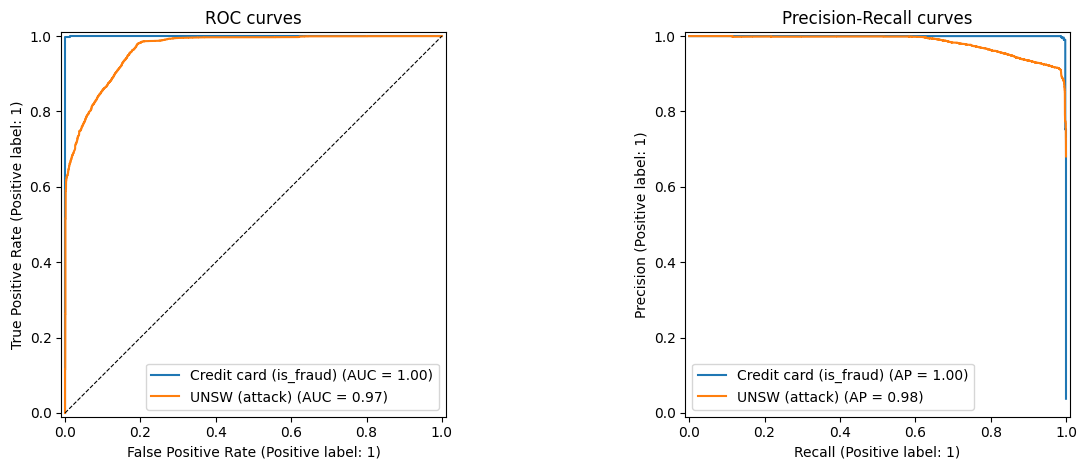

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for (Xe, ye, pr, pd_), lab in [(cc_eval, "Credit card (is_fraud)"), (u_eval, "UNSW (attack)")]:
    RocCurveDisplay.from_predictions(ye, pr, ax=ax[0], name=lab)
    PrecisionRecallDisplay.from_predictions(ye, pr, ax=ax[1], name=lab)
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0].set_title("ROC curves")
ax[1].set_title("Precision-Recall curves")
plt.tight_layout(); plt.show()

The contrast is striking. The credit-card ROC curve hugs the top-left corner
while the UNSW curve is strong but clearly below it. The precision-recall view is where logistic regression on UNSW shows its limits. Pushing
recall up costs precision which on a network-defense problem is the real operating decision. This is exactly the kind of
trade-off the synthetic credit-card data hides.

## Conclusions

* Logistic regression handles both targets well but tells two different stories. Credit-card
  fraud is classified almost perfectly because the data is synthetic and
  separable. UNSW attacks are detected strongly but imperfectly which is what a real detector
  looks like.
* Feature scaling is essential for fast convergence and interpretable coefficients, even
  though it does not change the ranking score much.
* The realistic value lives in UNSW where the precision-recall trade-off is a genuine
  operational choice. The credit-card result mainly serves as a cautionary example of how clean
  data can flatter a model.
